In [42]:
import rasterio
import numpy as np

TIFF_PATH = '../data/hja_all_2022.tif'  # update to wherever you saved the file from Drive

with rasterio.open(TIFF_PATH) as src:
    arr = src.read()          # (64, rows, cols), float32
    transform = src.transform
    crs = src.crs

# Flatten to a 2-D array of pixel vectors, dropping nodata pixels
embeddings_flat = arr.reshape(64, -1).T          # (n_pixels, 64)
valid_mask = np.all(np.isfinite(embeddings_flat), axis=1)
embeddings_flat = embeddings_flat[valid_mask]

print(f"Raster shape : {arr.shape}")              # (64, rows, cols)
print(f"Valid pixels : {embeddings_flat.shape}")  # (n_valid, 64)

Raster shape : (64, 1046, 2004)
Valid pixels : (2096184, 64)


In [43]:

from rasterio.transform import rowcol
# 3 random lon/lat points inside the AOI (same seed as EE call)
rng = np.random.default_rng(42)
lons = rng.uniform(-122.25240108713064, -122.07249996408376, size=3)
lats = rng.uniform(44.19136542920598,   44.28532650370888,  size=3)
coords = np.column_stack([lons, lats])  # (3, 2)

# Look up the pixel row/col for each point and extract all 64 bands
with rasterio.open(TIFF_PATH) as src:
    rows, cols = rowcol(src.transform, lons, lats)
    point_embeddings = src.read()[:, rows, cols].T  # (3, 64)

print("coords (lon, lat):\n", coords)
print("embeddings shape:", point_embeddings.shape)

coords (lon, lat):
 [[-122.11316552   44.25689088]
 [-122.17344636   44.20021443]
 [-122.09793836   44.28303595]]
embeddings shape: (3, 64)


In [44]:
from rasterio.windows import from_bounds
from rasterio.crs import CRS

MTBS_PATH = '../data/mtbs_CONUS_2023.tif'

AOI_BOUNDS = (-122.25240108713064, 44.19136542920598,
              -122.07249996408376, 44.28532650370888)  # west, south, east, north

with rasterio.open(MTBS_PATH) as src:
    # Reproject AOI bounds into the raster's CRS if needed
    if src.crs != CRS.from_epsg(4326):
        from rasterio.warp import transform_bounds
        bounds = transform_bounds('EPSG:4326', src.crs, *AOI_BOUNDS)
    else:
        bounds = AOI_BOUNDS

    window = from_bounds(*bounds, transform=src.transform)
    mtbs_clip = src.read(1, window=window)
    mtbs_transform = src.window_transform(window)
    mtbs_crs = src.crs
    mtbs_nodata = src.nodata

print(f"MTBS clip shape : {mtbs_clip.shape}")
print(f"CRS             : {mtbs_crs}")
print(f"Nodata value    : {mtbs_nodata}")
print(f"Unique values   : {np.unique(mtbs_clip)}")

MTBS clip shape : (466, 554)
CRS             : EPSG:5070
Nodata value    : 0.0
Unique values   : [0 1 2 3 4 5]


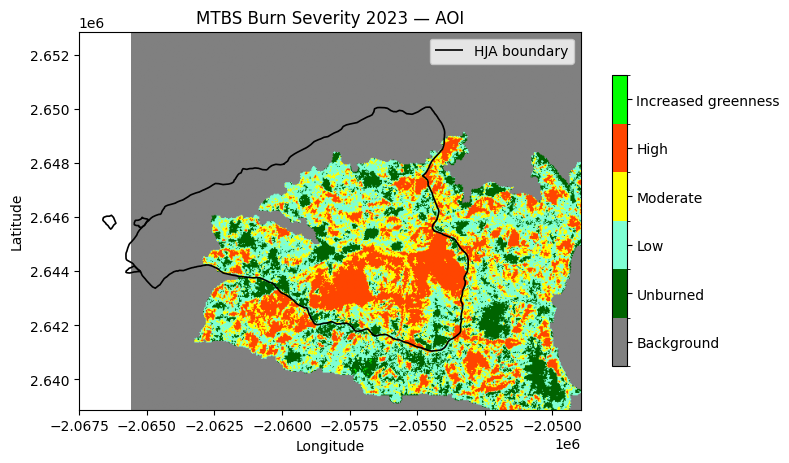

In [45]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd

# MTBS burn severity classes: 0=background, 1=unburned, 2=low, 3=moderate, 4=high, 5=increased greenness
cmap = mcolors.ListedColormap(['#808080', '#006400', '#7fffd4', '#ffff00', '#ff4500', '#00ff00'])
bounds_cls = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds_cls, cmap.N)
labels = ['Background', 'Unburned', 'Low', 'Moderate', 'High', 'Increased greenness']

# Compute imshow extent from the affine transform
nrows, ncols = mtbs_clip.shape
left   = mtbs_transform.c
top    = mtbs_transform.f
right  = left + mtbs_transform.a * ncols
bottom = top  + mtbs_transform.e * nrows  # e is negative for north-up
imshow_extent = (left, right, bottom, top)

# Load HJA boundary from GeoJSON (feature 0 = forest boundary, 1-3 = watersheds)
hja = gpd.read_file('../data/hja_baselayers.geojson').to_crs(mtbs_crs)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    mtbs_clip,
    cmap=cmap,
    norm=norm,
    extent=imshow_extent,
    origin='upper',
)
hja.boundary.plot(ax=ax, edgecolor='black', linewidth=1.2, label='HJA boundary')
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4, 5], shrink=0.7)
cbar.ax.set_yticklabels(labels)
ax.set_title('MTBS Burn Severity 2023 — AOI')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import geopandas as gpd
from rasterio.transform import xy
from rasterio.warp import transform as warp_transform
from rasterio.features import geometry_mask
from shapely.geometry import mapping

rng = np.random.default_rng(0)

# Rasterize HJA boundary onto the MTBS grid
hja_mtbs = gpd.read_file('../data/hja_baselayers.geojson').to_crs(mtbs_crs)
hja_mask_mtbs = geometry_mask(
    [mapping(geom) for geom in hja_mtbs.geometry],
    transform=mtbs_transform,
    invert=True,
    out_shape=mtbs_clip.shape,
)

# High-severity pixels inside the HJA boundary
high_rows, high_cols = np.where((mtbs_clip == 4) & hja_mask_mtbs)
if len(high_rows) == 0:
    raise ValueError("No high-severity pixels inside HJA boundary")

idx = rng.integers(len(high_rows))
mtbs_row, mtbs_col = high_rows[idx], high_cols[idx]

# xy() returns EPSG:5070 coordinates; reproject to AlphaEarth CRS for plotting
query_x, query_y = xy(mtbs_transform, mtbs_row, mtbs_col)
query_lon, query_lat = warp_transform(mtbs_crs, crs, [query_x], [query_y])
query_lon, query_lat = query_lon[0], query_lat[0]

print(f"Candidates inside HJA + high severity: {len(high_rows):,}")
print(f"Query location — lon={query_lon:.5f}, lat={query_lat:.5f}")

Candidates inside HJA + high severity: 13,584
Query location — lon=-122.13626, lat=44.21579


In [47]:
from rasterio.transform import rowcol

# query_lon/lat are already in the AlphaEarth CRS (EPSG:4326)
ae_row, ae_col = rowcol(transform, query_lon, query_lat)
ae_row = int(np.clip(ae_row, 0, arr.shape[1] - 1))
ae_col = int(np.clip(ae_col, 0, arr.shape[2] - 1))
query_vec = arr[:, ae_row, ae_col].astype(np.float32)  # (64,)
print(f"AlphaEarth pixel — row={ae_row}, col={ae_col}, embedding norm={np.linalg.norm(query_vec):.4f}")

AlphaEarth pixel — row=774, col=1293, embedding norm=0.9979


In [48]:
# Dot product between the query embedding and every pixel in the AOI
flat = arr.reshape(64, -1).T.astype(np.float32)  # (n_pixels, 64)
similarity = flat @ query_vec                      # (n_pixels,)
sim_raster = similarity.reshape(arr.shape[1], arr.shape[2])  # (rows, cols)
print(f"Similarity raster shape: {sim_raster.shape}")
print(f"Value range: {sim_raster.min():.3f} – {sim_raster.max():.3f}")

Similarity raster shape: (1046, 2004)
Value range: 0.268 – 1.002


In [49]:
from rasterio.warp import reproject, Resampling

# Reproject MTBS to AlphaEarth grid and build burn perimeter mask
burn_mask_ae = np.zeros((arr.shape[1], arr.shape[2]), dtype=np.uint8)
reproject(
    source=mtbs_clip.astype(np.uint8),
    destination=burn_mask_ae,
    src_transform=mtbs_transform,
    src_crs=mtbs_crs,
    dst_transform=transform,
    dst_crs=crs,
    resampling=Resampling.nearest,
)
burn_mask = burn_mask_ae > 0  # any MTBS class = inside burn perimeter
print(f"Burn perimeter pixels: {burn_mask.sum():,}")

Burn perimeter pixels: 1,186,014


In [50]:
import geopandas as gpd
from rasterio.features import geometry_mask
from shapely.geometry import mapping

# Rasterize HJA boundary to the AlphaEarth grid
hja_ae = gpd.read_file('../data/hja_baselayers.geojson').to_crs(crs)
hja_mask = geometry_mask(
    [mapping(geom) for geom in hja_ae.geometry],
    transform=transform,
    invert=True,  # True = inside HJA polygons
    out_shape=(arr.shape[1], arr.shape[2]),
)
print(f"HJA pixels: {hja_mask.sum():,}")

HJA pixels: 875,352


In [51]:
# Mask: inside HJA boundary but NOT inside the burn perimeter
combined_mask = hja_mask & ~burn_mask
sim_masked = np.where(combined_mask, sim_raster, np.nan)

print(f"Pixels inside HJA, outside burn perimeter: {combined_mask.sum():,}")
print(f"Similarity range: {np.nanmin(sim_masked):.3f} – {np.nanmax(sim_masked):.3f}")

Pixels inside HJA, outside burn perimeter: 275,594
Similarity range: 0.317 – 0.912


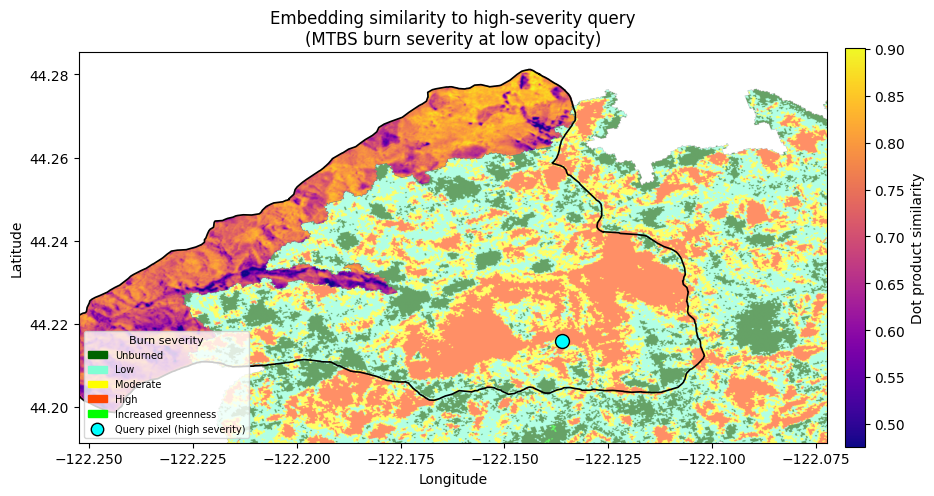

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from rasterio.warp import reproject, Resampling
import numpy as np

# Spatial extent from the AlphaEarth transform
nrows, ncols = arr.shape[1], arr.shape[2]
left   = transform.c
top    = transform.f
right  = left + transform.a * ncols
bottom = top  + transform.e * nrows
extent = (left, right, bottom, top)

# Reproject MTBS severity onto AlphaEarth grid
mtbs_ae = np.zeros((nrows, ncols), dtype=np.float32)
reproject(
    source=mtbs_clip.astype(np.float32),
    destination=mtbs_ae,
    src_transform=mtbs_transform,
    src_crs=mtbs_crs,
    dst_transform=transform,
    dst_crs=crs,
    resampling=Resampling.nearest,
)
mtbs_ae = np.where(mtbs_ae == 0, np.nan, mtbs_ae)

mtbs_colors = ['#006400', '#7fffd4', '#ffff00', '#ff4500', '#00ff00']
mtbs_labels = ['Unburned', 'Low', 'Moderate', 'High', 'Increased greenness']
mtbs_cmap = mcolors.ListedColormap(mtbs_colors)
mtbs_norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], mtbs_cmap.N)

# Similarity colormap with NaN → fully transparent
sim_cmap = plt.cm.plasma.copy()
sim_cmap.set_bad(alpha=0.0)

vmin = np.nanpercentile(sim_raster, 2)
vmax = np.nanpercentile(sim_raster, 98)

fig, ax = plt.subplots(figsize=(10, 6))

# Layer 1: MTBS burn severity
ax.imshow(mtbs_ae, cmap=mtbs_cmap, norm=mtbs_norm, extent=extent,
          origin='upper', alpha=0.6, zorder=1)

# Layer 2: similarity clipped to HJA, excluding burn perimeter
ax.imshow(sim_masked, cmap=sim_cmap, extent=extent, origin='upper',
          vmin=vmin, vmax=vmax, zorder=2)

# Layer 3: HJA boundary
for geom in hja_ae.geometry:
    for ring in ([geom.exterior] + list(geom.interiors) if hasattr(geom, 'exterior') else []):
        xs, ys = ring.xy
        ax.plot(xs, ys, color='black', linewidth=1.2, zorder=3)

# Layer 4: query pixel — plotted last so it's always on top
ax.scatter(query_lon, query_lat, color='cyan', edgecolor='black',
           s=100, zorder=10, label='Query pixel (high severity)')

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

# Similarity colorbar
sm = cm.ScalarMappable(cmap=sim_cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar1 = fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar1.set_label('Dot product similarity')

# Burn severity legend as colored patches
burn_patches = [mpatches.Patch(color=c, label=l)
                for c, l in zip(mtbs_colors, mtbs_labels)]
ax.legend(handles=burn_patches + [
    plt.scatter([], [], color='cyan', edgecolor='black', s=80, label='Query pixel (high severity)')
], loc='lower left', fontsize=7, title='Burn severity', title_fontsize=8)

ax.set_title('Embedding similarity to high-severity query\n(MTBS burn severity at low opacity)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [5]:
np.dot(point_embeddings[0], point_embeddings[1])


np.float64(0.8749353035334797)